# Power Grid Benchmark Analysis

Analysis of LLM performance on economic dispatch problems across difficulty levels (easy → very hard).

**Metrics:**
- **Success rate**: Fraction of attempts that pass (feasible + cost gap ≤ 5%)
- **Cost gap %**: How much more expensive the LLM schedule is vs optimal

In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aesthetic: clean, modern style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
with open('scores.yaml') as f:
    data = yaml.safe_load(f)

runs = data['runs']
print(f"Loaded {len(runs)} model runs")

Loaded 6 model runs


In [3]:
# Flatten into DataFrames for analysis
rows_overall = []
rows_by_diff = []

for run in runs:
    model = run['model']
    display_name = model.split('/')[-1].replace('-', ' ').title()
    
    rows_overall.append({
        'model': model,
        'display_name': display_name,
        'passed': run['overall']['passed'],
        'total': run['overall']['total'],
        'success_rate': run['overall']['success_rate']
    })
    
    for diff, stats in run['by_difficulty'].items():
        rows_by_diff.append({
            'model': model,
            'display_name': display_name,
            'difficulty': diff,
            'passed': stats['passed'],
            'total': stats['total'],
            'success_rate': stats['success_rate'],
            'avg_cost_gap_pct': stats['avg_cost_gap_pct']
        })

df_overall = pd.DataFrame(rows_overall)
df_by_diff = pd.DataFrame(rows_by_diff)

# Order difficulty for consistent plotting
diff_order = ['easy', 'medium', 'hard', 'very_hard']
df_by_diff['difficulty'] = pd.Categorical(df_by_diff['difficulty'], categories=diff_order, ordered=True)

df_overall

,model,display_name,passed,total,success_rate
0,openai/gpt-4o,Gpt 4O,5,20,0.25
1,openai/gpt-5.4-pro,Gpt 5.4 Pro,20,20,1.00
2,openai/gpt-5-nano,Gpt 5 Nano,17,20,0.85
3,anthropic/claude-sonnet-4.5,Claude Sonnet 4.5,10,20,0.50
4,anthropic/claude-sonnet-4.6,Claude Sonnet 4.6,14,20,0.70
5,mistralai/mistral-large-2512,Mistral Large 2512,2,20,0.10


## 1. Overall Success Rate by Model

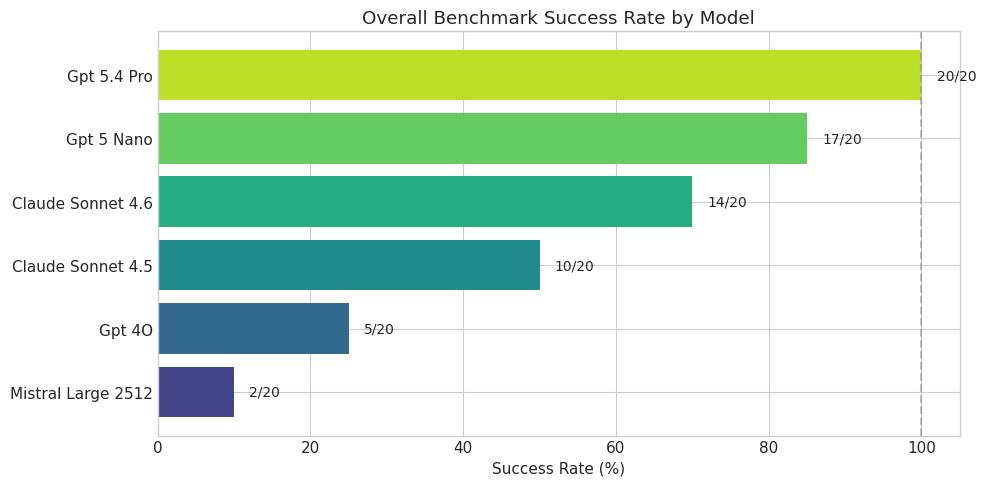

In [4]:
df_sorted = df_overall.sort_values('success_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df_sorted)))
bars = ax.barh(df_sorted['display_name'], df_sorted['success_rate'] * 100, color=colors)

ax.set_xlabel('Success Rate (%)')
ax.set_xlim(0, 105)
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Overall Benchmark Success Rate by Model')

for bar, row in zip(bars, df_sorted.itertuples()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
            f"{row.passed}/{row.total}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 2. Success Rate Heatmap (Model × Difficulty)

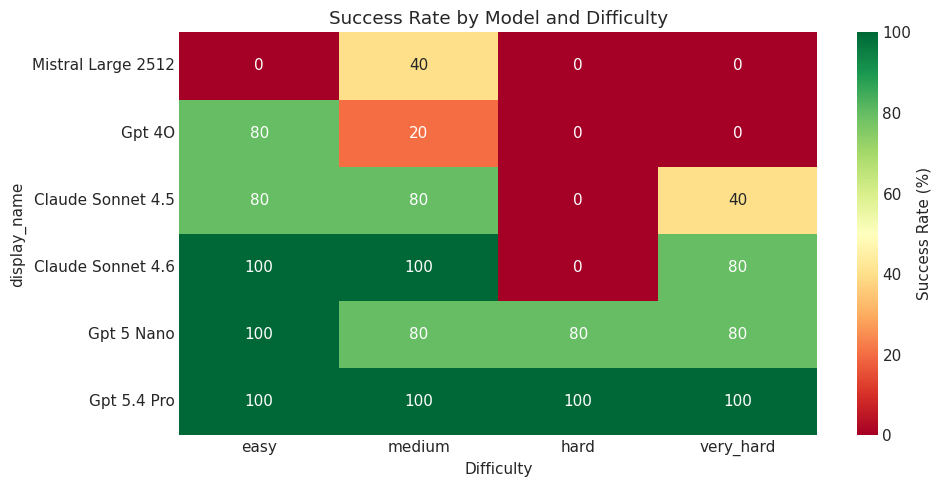

In [5]:
pivot = df_by_diff.pivot(index='display_name', columns='difficulty', values='success_rate')
# Sort by overall success (sum across difficulties)
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot * 100, annot=True, fmt='.0f', cmap='RdYlGn', center=50, 
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Success Rate (%)'})
ax.set_title('Success Rate by Model and Difficulty')
ax.set_xlabel('Difficulty')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Passed vs Total by Difficulty (Stacked Bar)

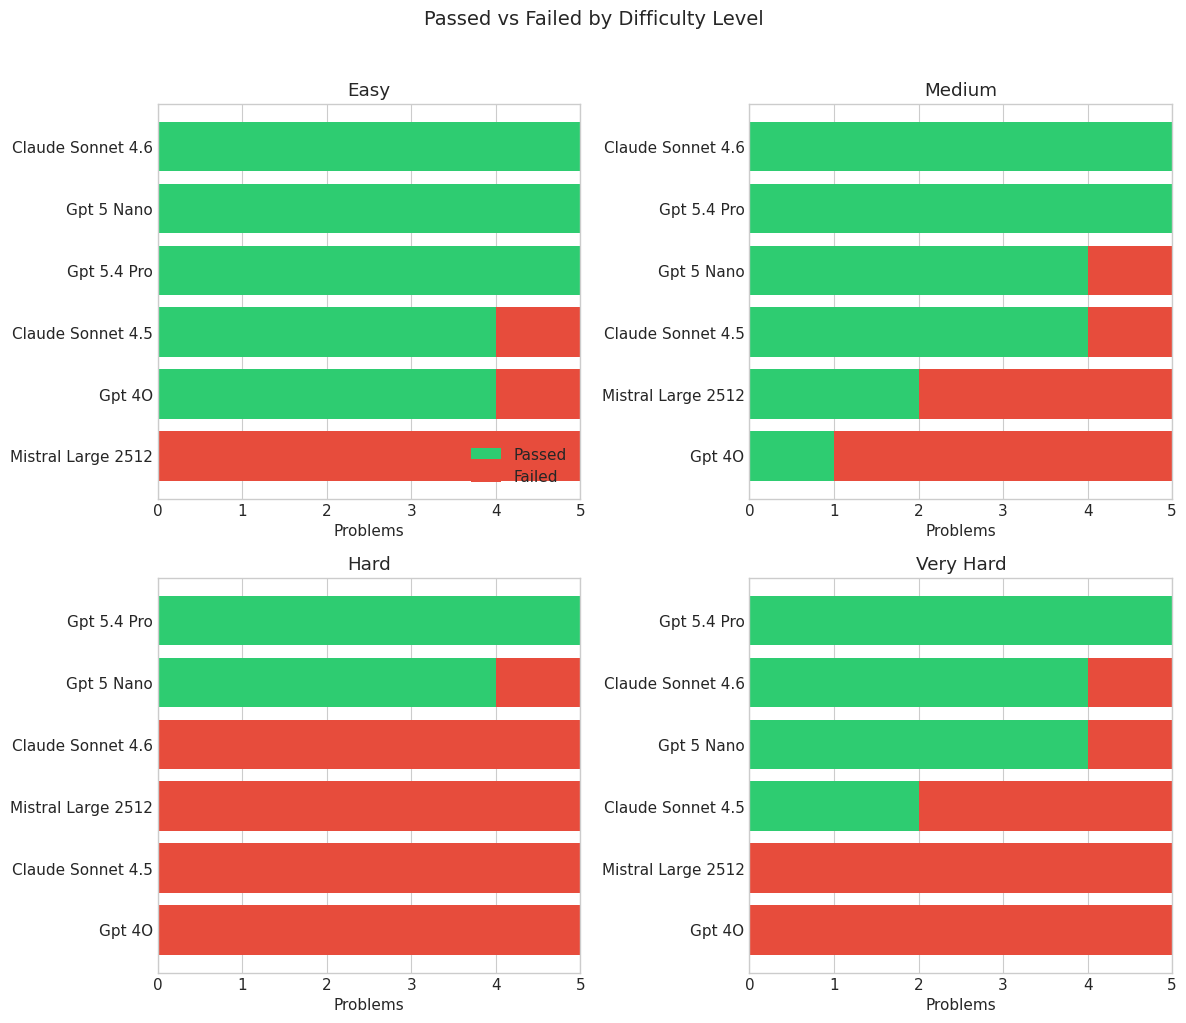

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

diff_labels = {'easy': 'Easy', 'medium': 'Medium', 'hard': 'Hard', 'very_hard': 'Very Hard'}

for i, diff in enumerate(diff_order):
    ax = axes[i]
    sub = df_by_diff[df_by_diff['difficulty'] == diff].sort_values('success_rate', ascending=True)
    
    x = range(len(sub))
    passed = sub['passed'].values
    failed = sub['total'].values - passed
    
    ax.barh(x, passed, label='Passed', color='#2ecc71')
    ax.barh(x, failed, left=passed, label='Failed', color='#e74c3c')
    ax.set_yticks(x)
    ax.set_yticklabels(sub['display_name'])
    ax.set_xlabel('Problems')
    ax.set_title(diff_labels[diff])
    ax.set_xlim(0, 5)

axes[0].legend(loc='lower right')
fig.suptitle('Passed vs Failed by Difficulty Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Average Cost Gap by Model and Difficulty

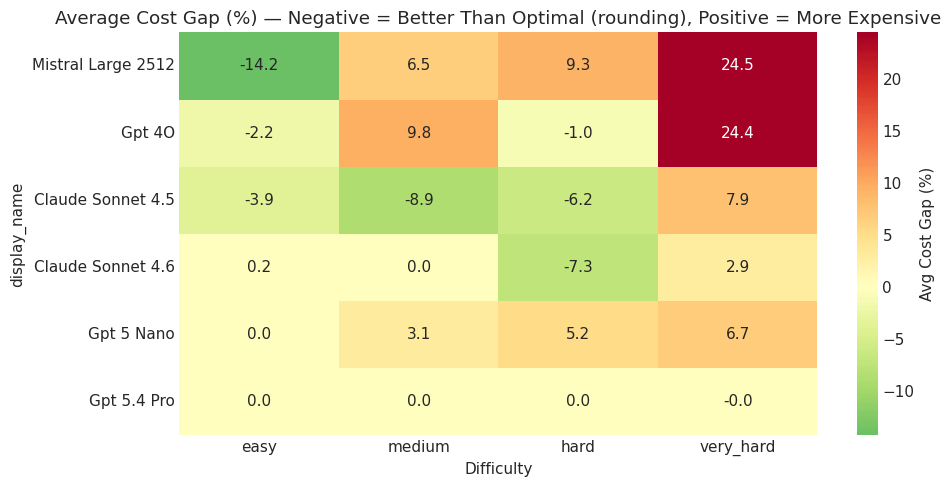

In [7]:
pivot_cost = df_by_diff.pivot(index='display_name', columns='difficulty', values='avg_cost_gap_pct')
pivot_cost = pivot_cost.loc[df_overall.sort_values('success_rate', ascending=True)['display_name']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_cost, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            ax=ax, cbar_kws={'label': 'Avg Cost Gap (%)'})
ax.set_title('Average Cost Gap (%) — Negative = Better Than Optimal (rounding), Positive = More Expensive')
ax.set_xlabel('Difficulty')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Grouped Bar: Success Rate by Difficulty

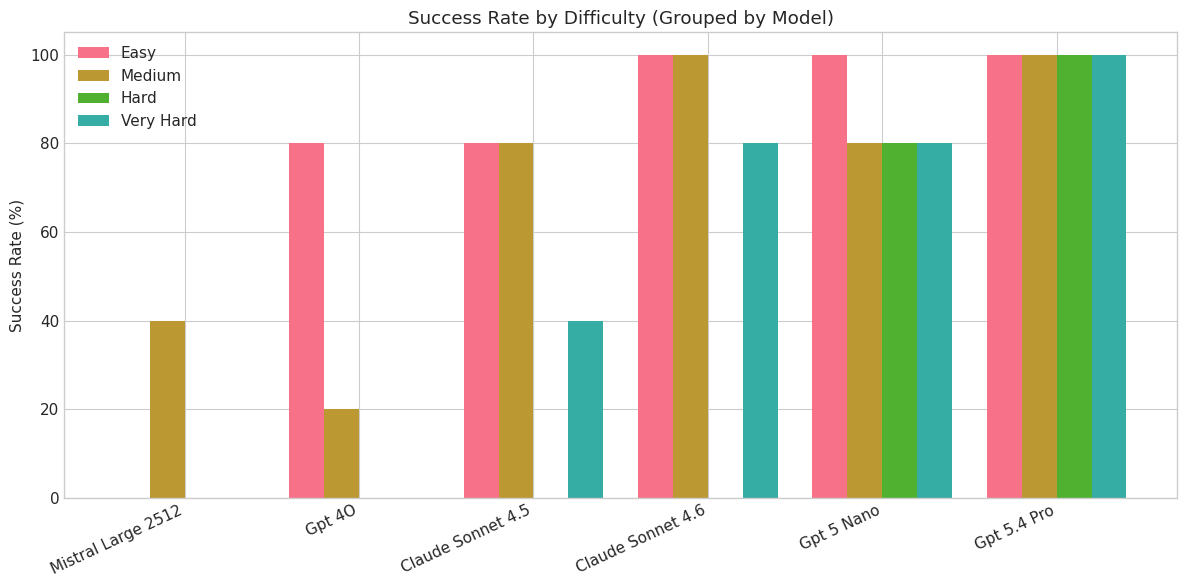

In [8]:
model_order = df_overall.sort_values('success_rate')['display_name'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_order))
width = 0.2

for i, diff in enumerate(diff_order):
    sub = df_by_diff[df_by_diff['difficulty'] == diff]
    ordered = sub.set_index('display_name').reindex(model_order)['success_rate'].fillna(0).values * 100
    offset = (i - 1.5) * width
    ax.bar(x + offset, ordered, width, label=diff.replace('_', ' ').title())

ax.set_ylabel('Success Rate (%)')
ax.set_title('Success Rate by Difficulty (Grouped by Model)')
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=25, ha='right')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 6. Summary Table

In [9]:
summary = df_overall.sort_values('success_rate', ascending=False)[['display_name', 'passed', 'total', 'success_rate']]
summary['success_rate'] = (summary['success_rate'] * 100).round(1).astype(str) + '%'
summary.columns = ['Model', 'Passed', 'Total', 'Success Rate']
summary

,Model,Passed,Total,Success Rate
1,Gpt 5.4 Pro,20,20,100.0%
2,Gpt 5 Nano,17,20,85.0%
4,Claude Sonnet 4.6,14,20,70.0%
3,Claude Sonnet 4.5,10,20,50.0%
0,Gpt 4O,5,20,25.0%
5,Mistral Large 2512,2,20,10.0%
